# BEoRN: Quick-start with Artificial Halos

This notebook is a self-contained introduction to BEoRN that requires **no external simulation data**. Instead of reading real cosmological simulations, it generates a simple set of artificial dark matter halos and evolves them with an idealised exponential mass-growth history. This makes it a fast and dependency-free way to explore the BEoRN workflow.

The notebook walks through the complete pipeline step by step:
1. Set astrophysical and simulation parameters
2. Create an artificial halo catalog
3. Pre-compute radial radiation profiles
4. Paint 3D signal maps across a range of redshifts
5. Visualise the resulting 21-cm brightness temperature maps and global history

> **Note:** The halo positions and masses used here are illustrative, not physically representative. For a realistic simulation use the `21cmfast_halos` notebook instead.

**Output:** Intermediate cached results are written to `./cache/` and final grids to `./output/`. Both are created automatically.

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
FILE_ROOT = Path(".")
CACHE_ROOT = FILE_ROOT / "cache"
OUTPUT_ROOT = FILE_ROOT / "output"

In [3]:
import beorn

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.titlesize': 14,
})


INFO:numexpr.utils:NumExpr defaulting to 10 threads.


## 1. Set simulation and astrophysical parameters

Here we define the cosmology, the simulation volume, and the astrophysical source model that describes how the first galaxies emit radiation.

- **Simulation:** box size (`Lbox`) and grid resolution (`Ncell`) set the spatial dynamic range. The halo mass bins define the range over which radiation profiles are pre-computed.
- **Source model:** the star formation efficiency (`f_st`), ionizing photon output (`Nion`), X-ray normalisation, and escape fraction control how strongly halos heat and ionize their surroundings. These are the parameters to explore when studying different reionization scenarios.

> For this illustrative run the source parameters are chosen to produce a clear visual signal, not to match observational constraints.

In [4]:
parameters = beorn.structs.Parameters()

## Simulation parameters, i.e. the allowed "dynamic range" of the simulation
parameters.simulation.cores = 60

parameters.solver.halo_mass_bin_min = 1e7
parameters.solver.halo_mass_bin_max = 1e15
parameters.solver.halo_mass_nbin = 200
parameters.solver.halo_mass_accretion_alpha = np.array([0.785, 0.795])
parameters.simulation.Lbox = 100
parameters.simulation.Ncell = 128

# Source age: how far back to integrate the emission history.
# z_source_start: no sources before this redshift (replaces hardcoded z=35).
# t_source_age: cap the lookback to this many Myr (None = use z_source_start only).
parameters.solver.z_source_start = 35.0  # default
parameters.source.t_source_age   = None  # default (no age cap)

## Source parameters
# emission
parameters.source.Nion = 5000 * 3
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 2000
parameters.source.energy_min_sed_xray = 500
parameters.source.energy_max_sed_xray = 2000
parameters.source.alS_xray = 1.5
parameters.source.xray_normalisation = 3.4e40 * 3

# fesc
parameters.source.f0_esc = 0.2
parameters.source.pl_esc = 0

# fstar
parameters.source.f_st = 1
parameters.source.g1 = 0
parameters.source.g2 = 0
parameters.source.g3 = 4
parameters.source.g4 = -1
parameters.source.Mp = 1.6e11 * parameters.cosmology.h
parameters.source.Mt = 1e7

# Minimum star forming halo
parameters.source.halo_mass_min = 1e5

## 2. Create the halo catalog

The `ArtificialHaloLoader` generates a set of halos placed randomly in the box, whose masses grow exponentially with time following a simple analytical prescription. This removes the need for a full N-body or semi-numerical simulation while still producing a realistic-looking halo distribution for demonstration purposes.

We also initialise the radiation profile solver here. It will use the same redshift grid as the halo loader.

In [5]:
cache_handler = beorn.io.Handler(CACHE_ROOT)
loader = beorn.load_input_data.ArtificialHaloLoader(
    parameters,
    halo_count = 100,
)

INFO:beorn.io.handler:Using persistence directory at cache


## 3. Pre-compute radiation profiles

BEoRN pre-computes 1D radial profiles describing how X-ray heating, Lyman-alpha flux, and ionization decrease with distance from a halo of a given mass. This step only needs to run once per set of astrophysical parameters — the results are cached on disk and reloaded automatically on subsequent runs.

In [6]:
solver = beorn.precomputation.RadiationProfileSolver(parameters, loader.redshifts)
profiles = solver.get_or_compute_profiles(cache_handler)

INFO:beorn.precomputation.solver:Loaded radiation profiles from cache (z=24.50→6.00, 38 steps).


## 4. Inspect the halo distribution

As a quick sanity check, we project the halo positions onto the 2D plane to confirm that they are distributed throughout the simulation box. Each pixel shows the number of halos along the line of sight.

INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.


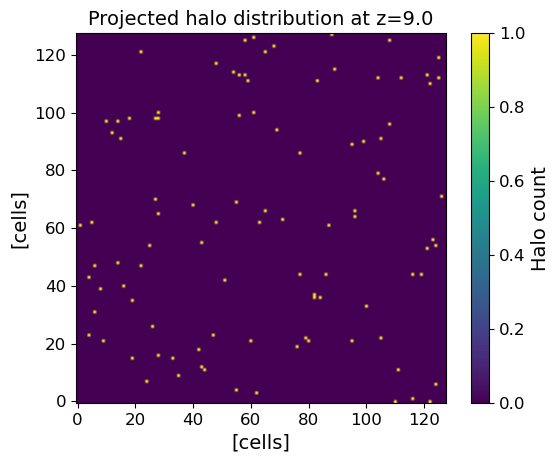

In [7]:
z_target = 9.0
z_index = np.argmin(np.abs(loader.redshifts - z_target))
halo_catalog = loader.load_halo_catalog(z_index)

mesh = halo_catalog.to_mesh()
stacked_mesh = np.sum(mesh, axis=0)

plt.figure()
plt.imshow(stacked_mesh, origin='lower', cmap='viridis')
plt.colorbar(label='Halo count')
plt.xlabel('[cells]')
plt.ylabel('[cells]')
plt.title(f'Projected halo distribution at z={z_target}')
plt.show()

## 5. Paint the 3D signal maps

BEoRN places the pre-computed radiation profiles around each halo and accumulates their contributions on the 3D grid. The result is a time-series of coeval cubes, each containing the ionization fraction, gas temperature, and Lyman-alpha coupling field at a given redshift. From these, the 21-cm brightness temperature $\delta T_b$ is computed.

In [8]:
output_handler = beorn.io.Handler(OUTPUT_ROOT)

p = beorn.painting.PaintingCoordinator(
    parameters,
    loader=loader,
    output_handler=output_handler,
)

multi_z_quantities = p.paint_full(profiles)

INFO:beorn.io.handler:Using persistence directory at output
INFO:beorn.painting.coordinator:============================================================
BEoRN model summary
  Cosmology   : Om=0.31, Ob=0.045, h=0.68, sigma_8=0.83
  Grid        : Ncell=128, Lbox=100 Mpc/h
  Profile z   : z=25.0 -> 6.5 (38 steps)
  1D RT bins  : 1.0e+07 - 1.0e+15 Msun at z=6.5 (200 bins, traced back via exp. accretion)
  Source      : f_st=1, Nion=15000, f0_esc=0.2
  X-ray       : norm=1.02e+41, E=[500, 2000] eV
  Lyman-alpha : n_phot=9690, star-forming above 1.0e+05 Msun
  Beorn hash  : a62f0240
INFO:beorn.painting.coordinator:Painting profiles onto grid for 38 of 38 redshift snapshots. Using 60 processes on a single node.


Painting redshift snapshots:   0%|          | 0/38 [00:00<?, ?snapshot/s]

INFO:beorn.painting.coordinator:Found painted output for z=24.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=24.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=23.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=23.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=22.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=22.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=21.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=21.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=20.500 — skip

## 6. Visualise the 3D maps at a single redshift

We show 2D slices through the simulation box for the ionization fraction $x_\mathrm{HII}$ and the 21-cm brightness temperature $\delta T_b$ at the chosen redshift. The ionized regions appear around the halo positions seen above.

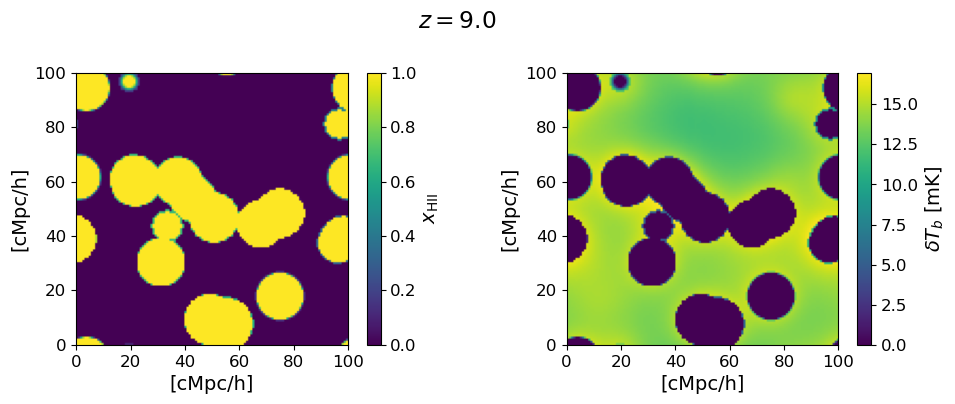

In [9]:
Lbox = parameters.simulation.Lbox
extent = [0, Lbox, 0, Lbox]
mz_index = np.argmin(np.abs(multi_z_quantities.z - z_target))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, grid, label in zip(
    axes,
    [multi_z_quantities.Grid_xHII[mz_index, :, 64, :],
     multi_z_quantities.Grid_dTb[mz_index, :, 64, :]],
    [r'$x_\mathrm{HII}$', r'$\delta T_b$ [mK]'],
):
    im = ax.imshow(grid, origin='lower', cmap='viridis', extent=extent)
    ax.set_xlabel('[cMpc/h]')
    ax.set_ylabel('[cMpc/h]')
    fig.colorbar(im, ax=ax, label=label)

fig.suptitle(f'$z = {z_target}$')
plt.tight_layout()
plt.show()

## 7. Global history and power spectra

The global (volume-averaged) signal shows how reionization unfolds over time. The panels show the mean 21-cm brightness temperature, gas kinetic temperature, and ionization fraction as a function of redshift, alongside the 21-cm power spectrum amplitude at a fixed wavenumber.

Power spectrum:   0%|          | 0/38 [00:00<?, ?snapshot/s]

k=0.12 Mpc$^{-1}$


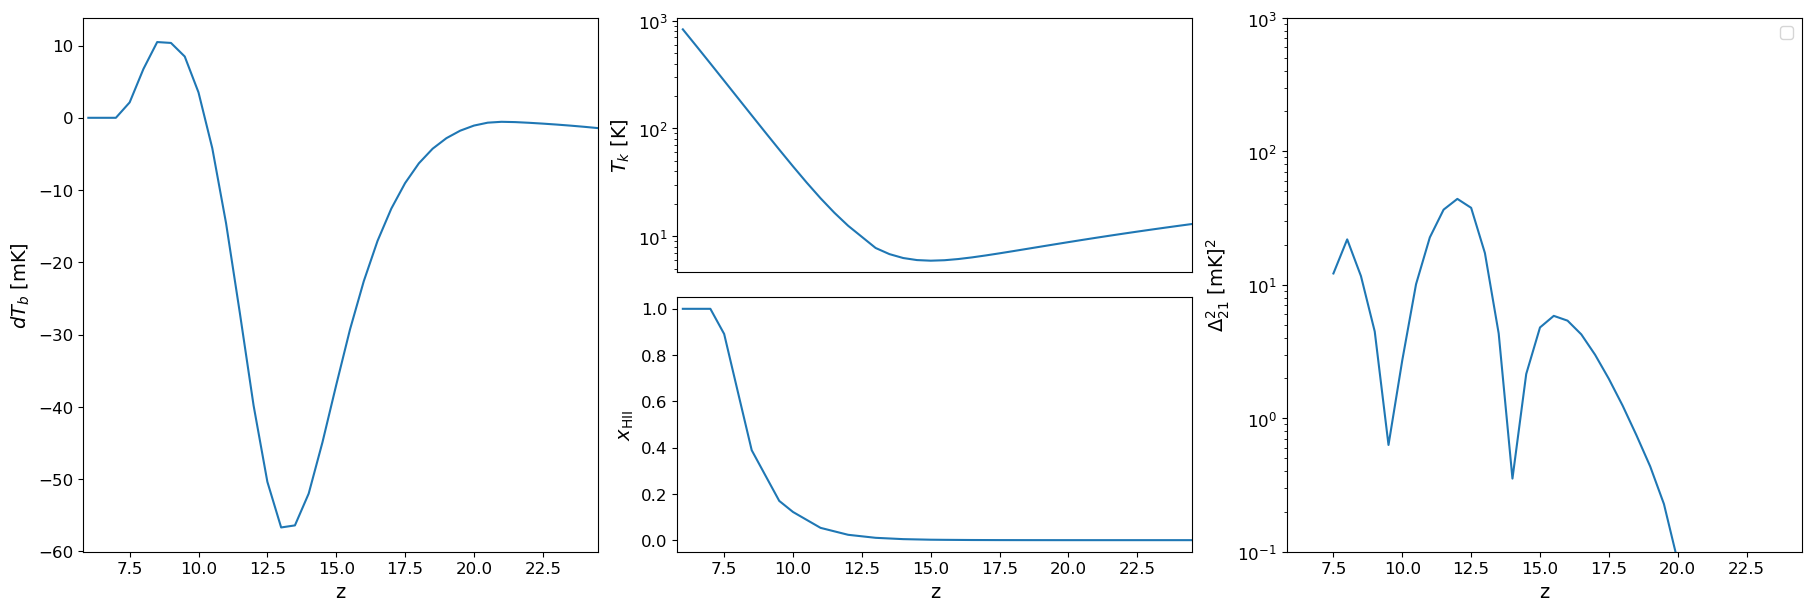

In [10]:
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities)
beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities)
beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities)
beorn.plotting.draw_dTb_power_spectrum_of_z(ax4, multi_z_quantities, parameters)

ax4.legend(loc='best')
ax2.axes.get_xaxis().set_visible(False)
plt.show()

## 8. Lightcone

A lightcone combines slices from different redshifts along the line of sight, mimicking how a radio telescope actually observes the signal: looking further away means looking further back in time. The redshift increases from left to right, tracing the evolution of the 21-cm signal through the EoR.

Making lightcone between 0.039216 < z < 0.142703


100%|██████████| 547/547 [00:00<00:00, 4988.64it/s]

...done


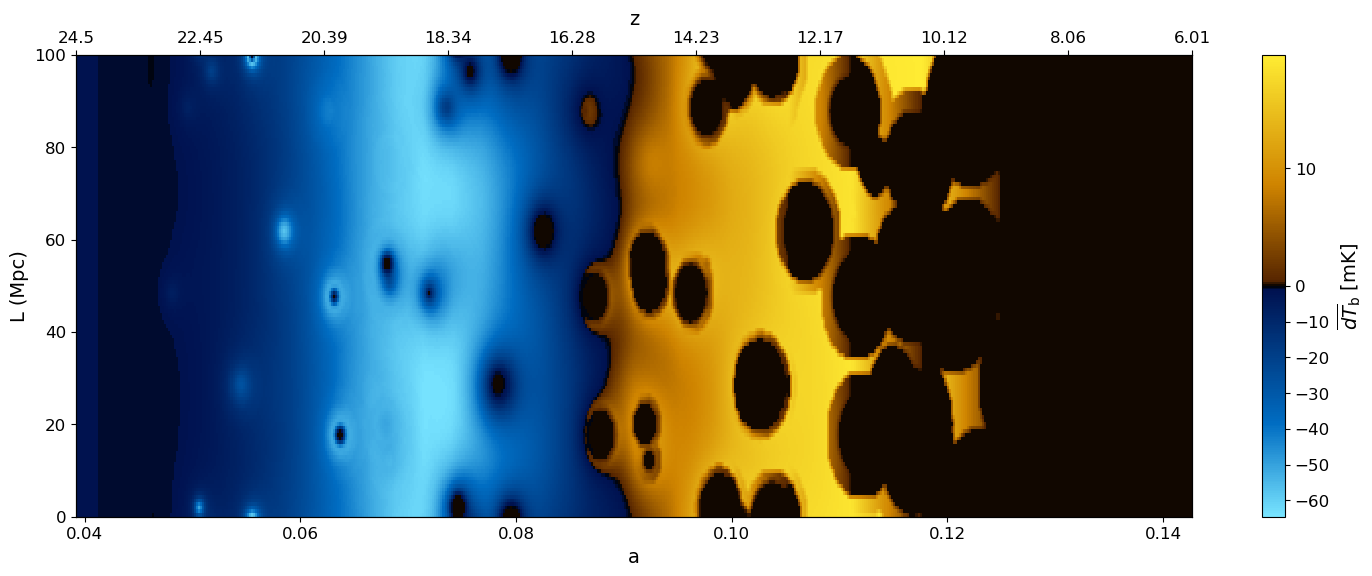

In [11]:
lightcone = beorn.structs.Lightcone.build(
    parameters,
    multi_z_quantities,
    quantity="Grid_dTb",
)

fig, ax = plt.subplots(figsize=(18, 6))
beorn.plotting.plot_lightcone(lightcone, ax, "", slice_number=80)
plt.show()